In [2]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [3]:
#gl_source = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
gl_source = ['STAT3','IL6R', 'IL6ST','TGFBR1','TGFBR2','PDGFB'] # All values from the first column

gl_recv =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column

In [4]:
from scipy.sparse import issparse

ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 1414 × 6
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 6
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [8]:
import sys
import os

# Replace with your actual path
#cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
cc_grn_functions_path = r"C:\Users\selim\Documentos\vscode_working_dir\QuantumXCT\python\cc_grn_functions"

sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

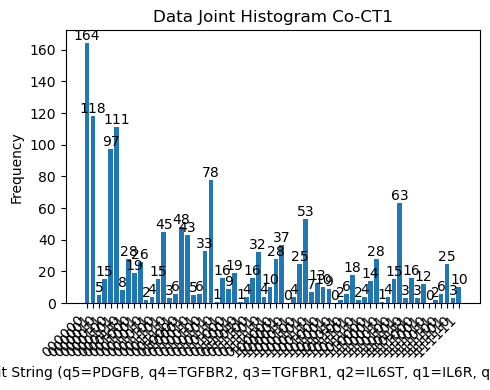

Joint Counts: Counter({'000000': 164, '000001': 118, '000101': 111, '000100': 97, '010101': 78, '110101': 63, '100101': 53, '010000': 48, '001101': 45, '010001': 43, '100001': 37, '010100': 33, '011101': 32, '100000': 28, '000111': 28, '110001': 28, '001001': 26, '111101': 25, '100100': 25, '001000': 19, '011001': 19, '101101': 18, '011100': 16, '110111': 16, '010111': 16, '001100': 15, '110100': 15, '000011': 15, '110000': 14, '100111': 13, '111001': 12, '101000': 10, '011111': 10, '111111': 10, '011000': 9, '101001': 9, '000110': 8, '100110': 7, '101100': 6, '010011': 6, '001111': 6, '111100': 6, '000010': 5, '010010': 5, '011110': 4, '011011': 4, '001011': 4, '100011': 4, '110011': 4, '101111': 4, '111110': 3, '110110': 3, '001110': 3, '111000': 3, '111011': 2, '001010': 2, '101110': 2, '101011': 2, '110010': 1, '010110': 1, '011010': 1})
Bit Strings: ['000000', '000001', '000010', '000011', '000100', '000101', '000110', '000111', '001000', '001001', '001010', '001011', '001100', '0

In [9]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), 
                     #filename = 'joint_counts_co_ct1.svg', 
                     title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

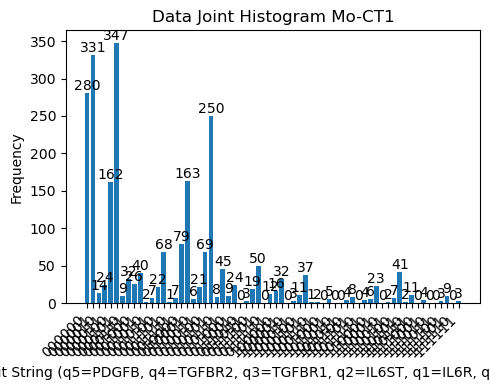

Joint Counts: Counter({'000101': 347, '000001': 331, '000000': 280, '010101': 250, '010001': 163, '000100': 162, '010000': 79, '010100': 69, '001101': 68, '011101': 50, '010111': 45, '110101': 41, '001001': 40, '100101': 37, '100001': 32, '000111': 32, '001000': 26, '000011': 24, '011001': 24, '110001': 23, '001100': 22, '010011': 21, '011100': 19, '100000': 16, '000010': 14, '011111': 12, '110111': 11, '100100': 11, '011000': 9, '111101': 9, '000110': 9, '010110': 8, '101101': 8, '001011': 7, '001111': 7, '110100': 7, '010010': 6, '110000': 6, '101001': 5, '101111': 4, '111001': 4, '101100': 4, '100011': 3, '111100': 3, '011011': 3, '111111': 3, '001010': 2, '110110': 2, '100111': 2, '110011': 2, '100110': 1, '001110': 1})
Bit Strings: ['000000', '000001', '000010', '000011', '000100', '000101', '000110', '000111', '001000', '001001', '001010', '001011', '001100', '001101', '001110', '001111', '010000', '010001', '010010', '010011', '010100', '010101', '010110', '010111', '011000', '0

In [10]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4),
                     #filename = 'joint_counts_mo_ct1.svg', 
                     title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

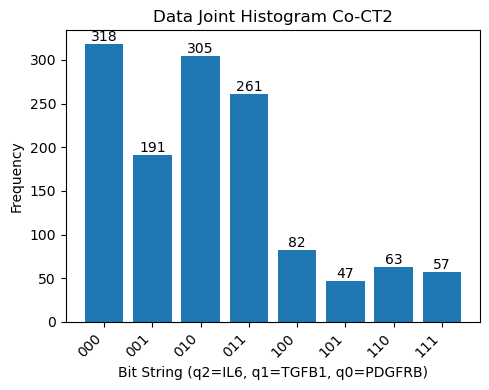

Joint Counts: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [11]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), 
                     #filename = 'joint_counts_co_ct2.svg', 
                     title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

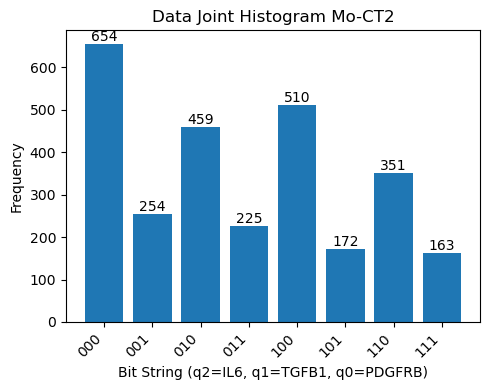

Joint Counts: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [12]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), 
                     #filename = 'joint_counts_mo_ct2.svg', 
                     title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [13]:
from quantum_functions import vector_normalize_dictionary_values, create_initial_circuit2

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'000101': 347, '000001': 331, '000000': 280, '010101': 250, '010001': 163, '000100': 162, '010000': 79, '010100': 69, '001101': 68, '011101': 50, '010111': 45, '110101': 41, '001001': 40, '100101': 37, '100001': 32, '000111': 32, '001000': 26, '000011': 24, '011001': 24, '110001': 23, '001100': 22, '010011': 21, '011100': 19, '100000': 16, '000010': 14, '011111': 12, '110111': 11, '100100': 11, '011000': 9, '111101': 9, '000110': 9, '010110': 8, '101101': 8, '001011': 7, '001111': 7, '110100': 7, '010010': 6, '110000': 6, '101001': 5, '101111': 4, '111001': 4, '101100': 4, '100011': 3, '111100': 3, '011011': 3, '111111': 3, '001010': 2, '110110': 2, '100111': 2, '110011': 2, '100110': 1, '001110': 1})
State Set CT2 MO: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Interacted State Set CT1 CO: Counter({'000000': 164, '000001': 118, '000101': 111, '000100': 97, '01010

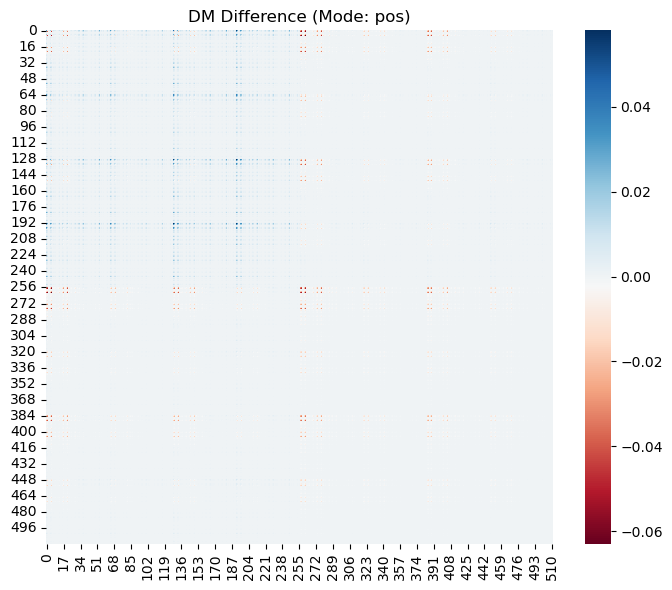


--- CNOT Analysis (pos) ---
Max Signal: 0.0580
Candidates Found: 20 / 72
------------------------------

{'max_element': 0.05800628074614404, 'min_element': -0.06292988485093101, 'abs_average': 0.0003735912714108467, 'relevant_avg': 0.0003436624533334513}


In [19]:
from quantum_functions import find_cnot_candidates_from_state_diff

thresh = 0.02
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, show_plot = True, search_mode="pos" , 
    verbose_print = True)

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


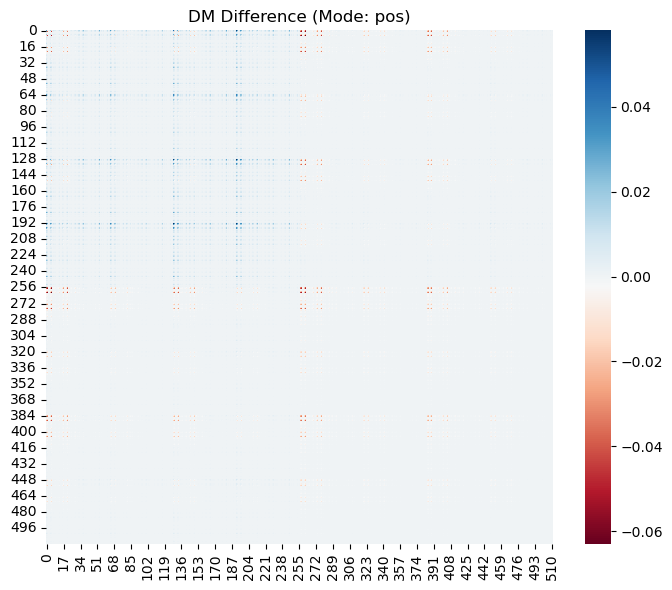


--- CNOT Analysis (pos) ---
Max Signal: 0.0580
Candidates Found: 20 / 72
------------------------------

Number of initial CNOT candidates: 20
Initial KL-divergence: 0.891955

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 0.902007 ---
  [Phase 2] Added Pair: ((0, 6), (0, 7)) | New KL: 0.781673

--- Iteration 2 | Current KL: 0.781673 ---
  [Phase 2] Added Pair: ((2, 7), (6, 5)) | New KL: 0.674629
   - Deletion Phase: Best Removed (2, 7). New KL: 0.675657

--- Iteration 3 | Current KL: 0.674629 ---
  - No improvements in any phase. Search Terminated.

--- Total Search Time: 403.55s ---

--- Pairwise Addition Result ---
Best sequence after addition: [(0, 6), (0, 7), (2, 7), (6, 5)]
KL sum after addition: 0.674629

Total search time: 404.30 seconds.

Multi-Epoch Search Optimal CNOT sequence found:
  q[0] -> q[6]
  q[0] -> q[7]
  q[2] -> q[7]
  q[6] -> q[5]
With minimum combined KL Divergence: 0.674629

--- Final Optimized Circuit ---
              »
         q_

In [21]:
from quantum_functions import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    search_mode= "pos",
    nchoose=2,
    kl_tol = 0.1, 
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'000000': 767, '100001': 318, '000100': 261, '000001': 875, '000101': 1005, '010101': 563, '010001': 236, '010000': 53, '100101': 347, '011101': 20, '100000': 69, '001100': 2, '110101': 202, '110001': 72, '111101': 10, '010100': 43, '001101': 37, '001000': 8, '110100': 5, '100111': 4, '100100': 32, '011001': 4, '001001': 8, '110111': 4, '000011': 2, '010111': 10, '011100': 5, '000111': 8, '101101': 11, '001111': 2, '000010': 1, '110000': 2, '011111': 1, '111001': 2, '010011': 4, '101000': 1, '011000': 1, '101001': 3, '110011': 1, '101100': 1}
Counts for c_measure2: {'010': 933, '111': 473, '001': 572, '000': 892, '011': 744, '100': 501, '110': 575, '101': 310}


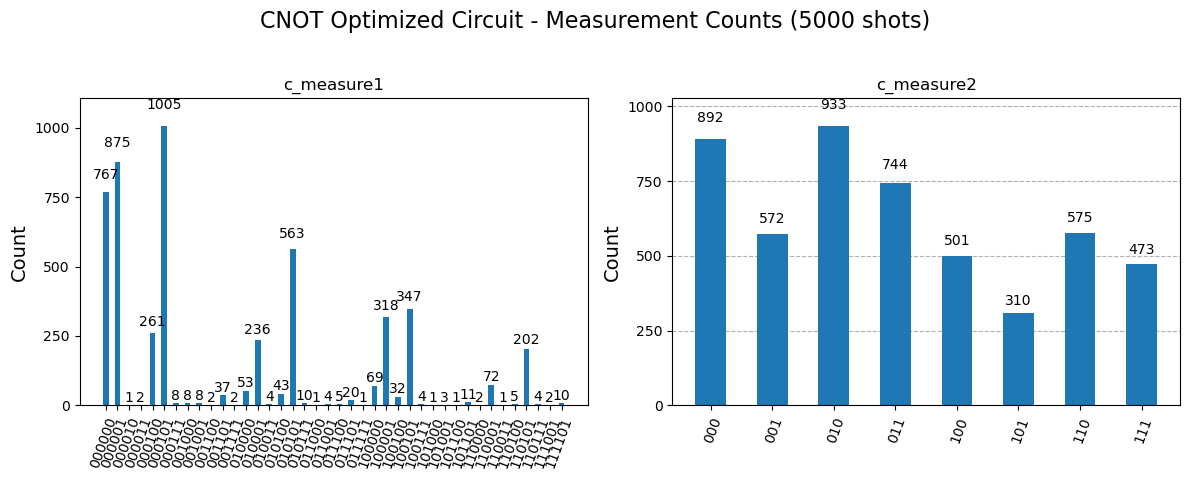

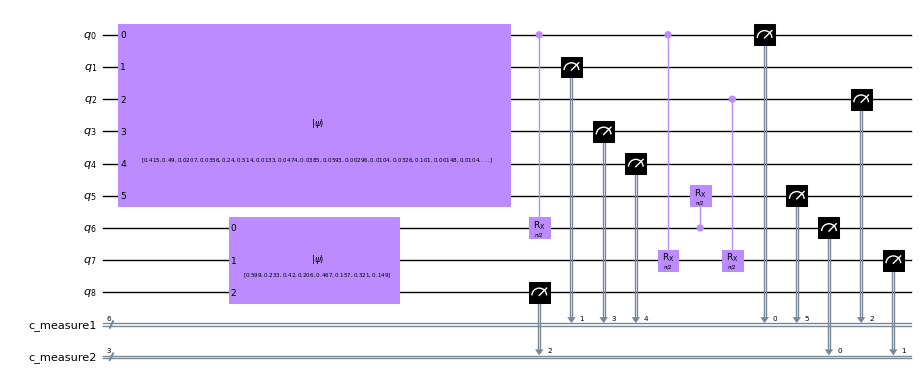

In [22]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

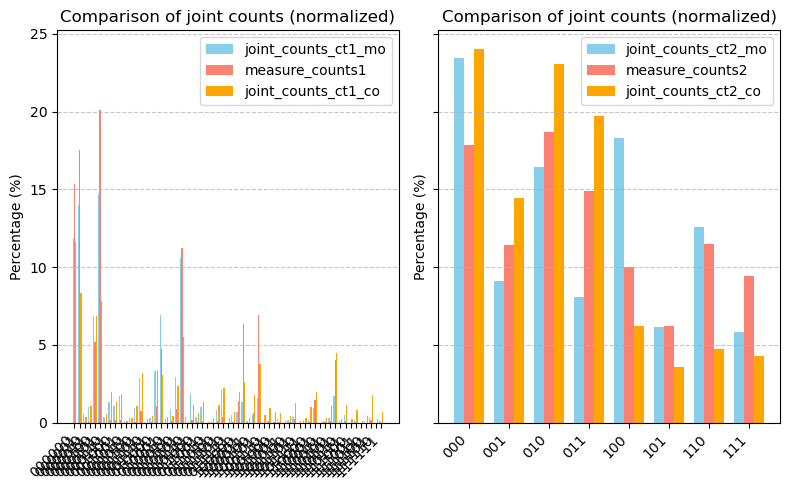

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


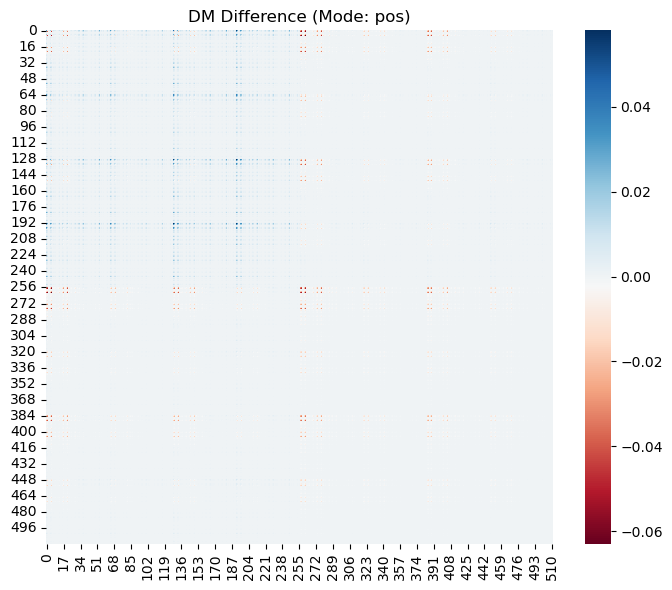


--- CNOT Analysis (pos) ---
Max Signal: 0.0580
Candidates Found: 20 / 72
------------------------------

Initial KL divergence (baseline): 0.913433

--- Starting Epoch 1/20 (Addition) with CNOT: (4, 7) (KL: 0.891919) ---
    --> Found a better KL on this path: 0.782273 at depth 2 with added CNOT (7, 5)
    --> Found a better KL on this path: 0.716278 at depth 3 with added CNOT (0, 6)
    --> Found a better KL on this path: 0.648124 at depth 4 with added CNOT (0, 7)
  Epoch 1 best KL Sum: 0.648124
  --> Epoch 1 found a new overall best KL Sum: 0.648124

--- Starting Greedy CNOT Removal Search on Best Found Sequence ---
  Starting removal search with 4 CNOTs (KL Sum: 0.648124)
  No CNOT removal improved the score. Stopping removal search.

--- Starting Epoch 2/20 (Addition) with CNOT: (2, 6) (KL: 0.866520) ---
    --> Found a better KL on this path: 0.679319 at depth 2 with added CNOT (6, 5)
    --> Found a better KL on this path: 0.658298 at depth 3 with added CNOT (7, 0)
    --> Found

In [25]:
from quantum_functions import find_best_cnot_sequence_multi_epoch

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 20

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=thresh,
    search_mode="pos",
    kl_tol = 0.1,
    ratio_kl_tol = 0.6
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'000001': 1158, '000000': 841, '010101': 521, '000101': 972, '001000': 13, '100001': 95, '000100': 212, '100100': 61, '010001': 267, '010000': 53, '100101': 323, '001101': 30, '100000': 77, '010011': 4, '110111': 2, '011001': 6, '110101': 181, '110000': 4, '010110': 1, '101101': 16, '010111': 20, '010100': 34, '110100': 13, '111101': 7, '110001': 30, '111100': 1, '011101': 23, '000111': 8, '001001': 8, '001100': 2, '101100': 1, '011100': 2, '100110': 1, '111001': 1, '011111': 1, '010010': 2, '100111': 1, '111111': 1, '001011': 1, '101000': 2, '000011': 4}
Counts for c_measure2: {'000': 1398, '100': 844, '001': 630, '110': 407, '010': 761, '101': 367, '011': 389, '111': 204}


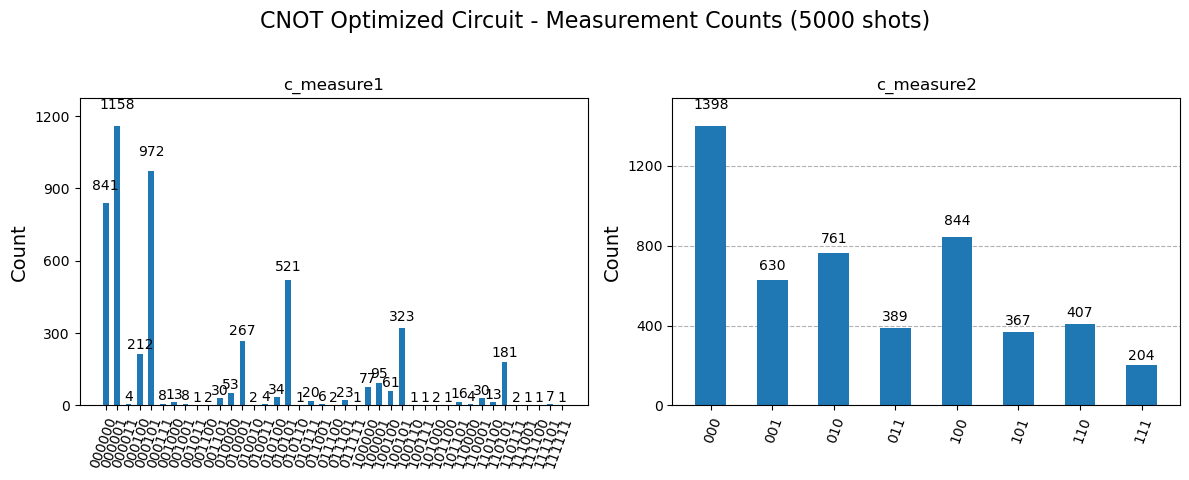

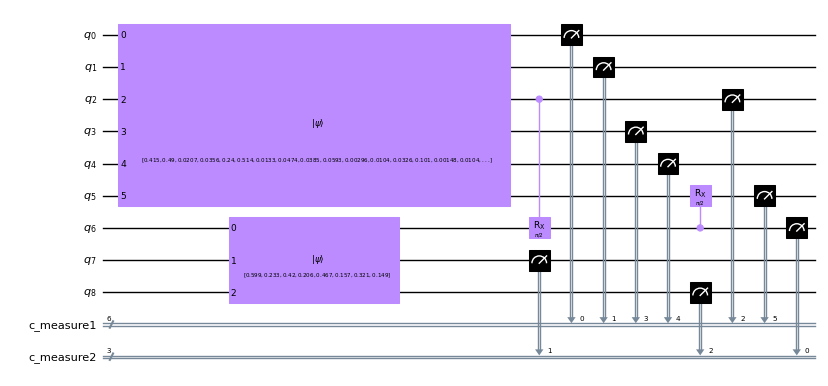

In [26]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

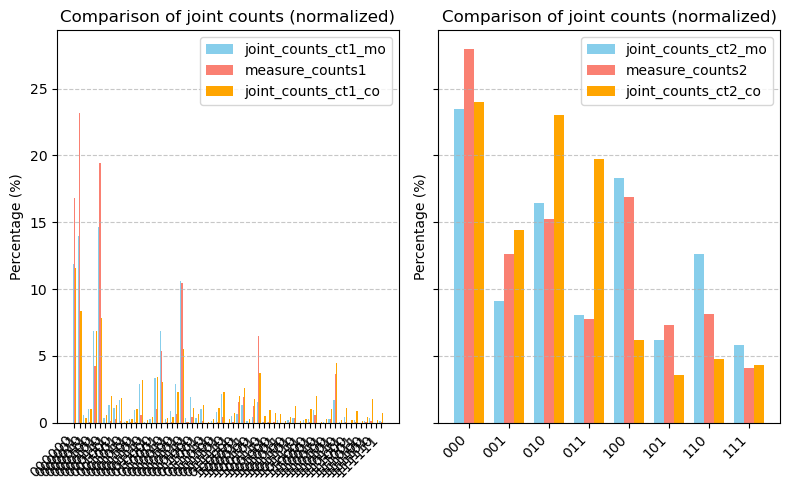

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (2 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.4779', '1.7194']
CRX Angle Optimization took: 13.64 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.4779', '1.7194']
  Minimum Combined KL Divergence with Optimized CRX: 0.756201


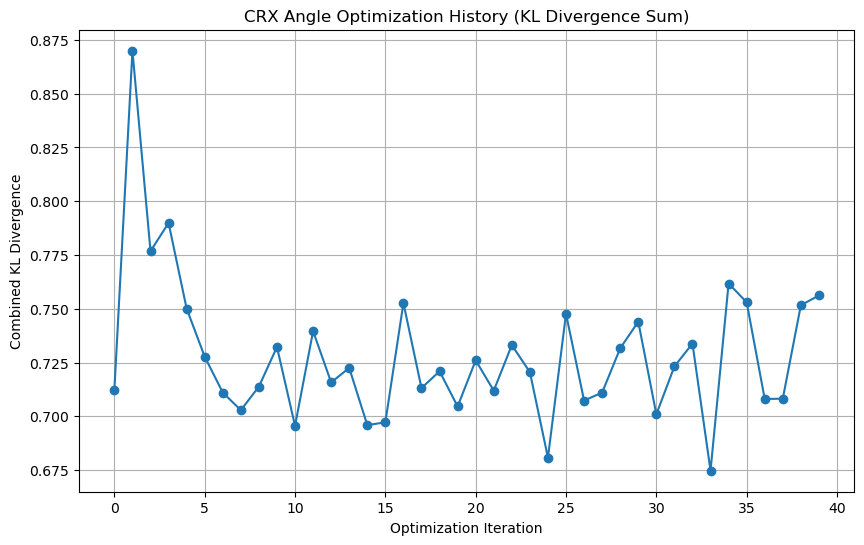


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
         q_7: »
              »
         q_8: »
              »
c_measure1: 6/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                        

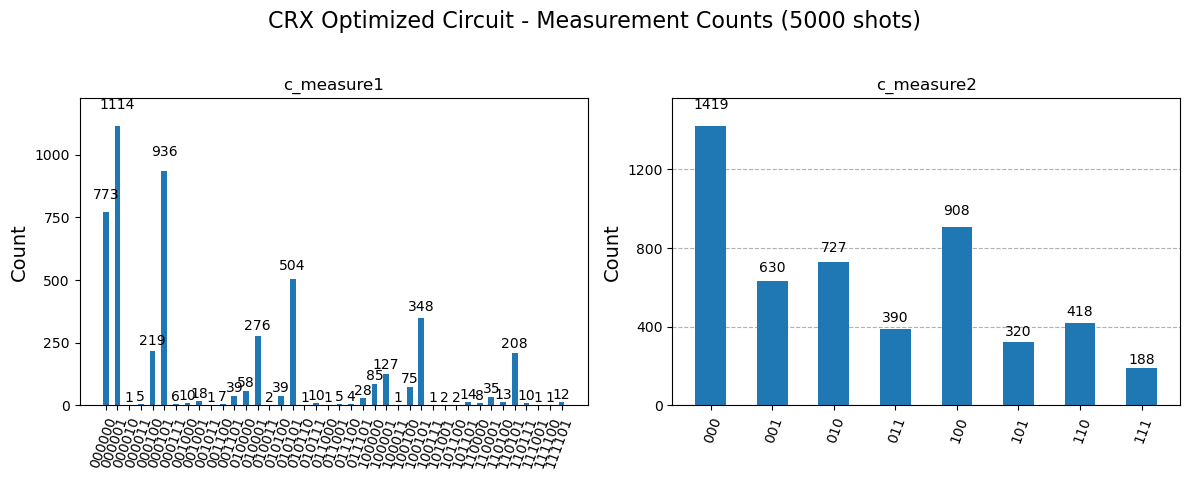

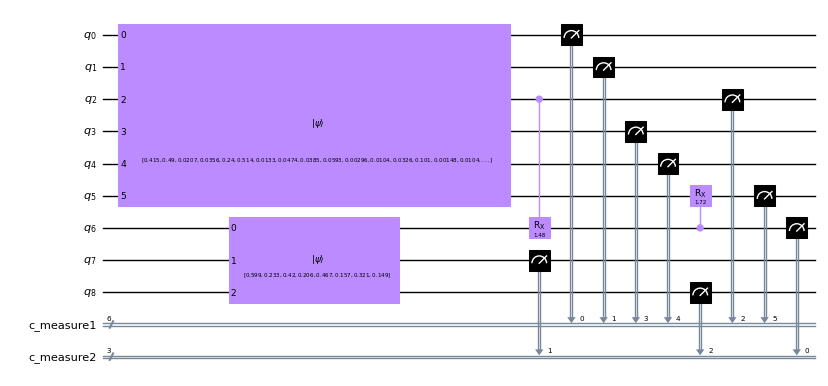

In [28]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

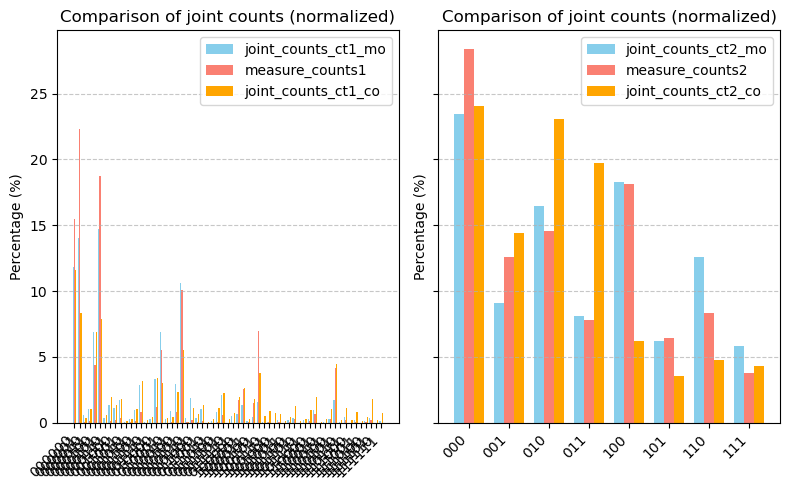

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts_anglkes.svg')



--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


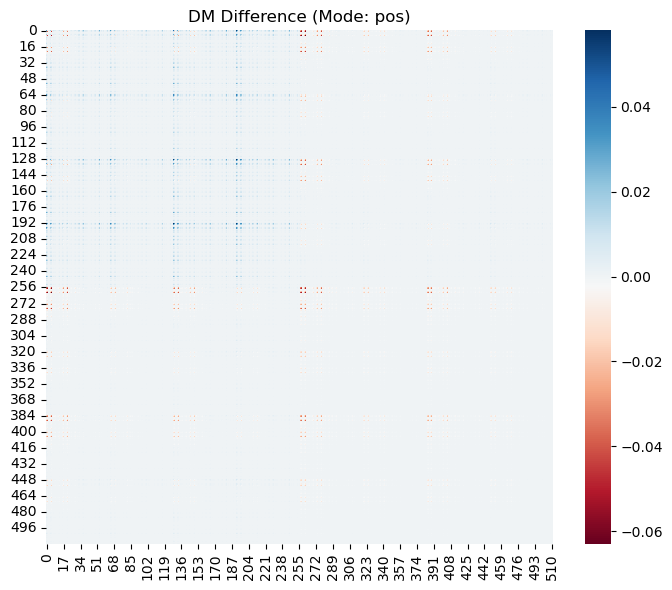


--- CNOT Analysis (pos) ---
Max Signal: 0.0580
Candidates Found: 20 / 72
------------------------------

Initial KL Divergence (no CNOTs): 0.899151

--- Building KL Divergence Matrix (20x20) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 380
--- KL Divergence Matrix Built ---


In [31]:
from quantum_functions import build_kl_divergence_matrix_interaction

thresh = 0.02
np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)

kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh, 
    search_mode= "pos",
    include_single_cnot_kl=True
)

In [32]:
from quantum_functions import kl_to_qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [33]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

-0.4022780834730092
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIZIIZ', 'IIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIZIIIIIZ', 'IIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIZIIIIIIZ', 'IIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIZIIIIIIIZ', 'IIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIZIIIIIIIIZ', 'IIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIIIIIIZ', 'IIIIIIIIIZIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIIZ', 'IIIIIIIIZIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIIZ', 'IIIIIIIZIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIIZ', 'IIIIIIZIIIIIIIIIIIII', 'IIIIIZIIIIIIIIIIIIIZ', 'IIIIIZIIIIIIIIIIIIII', 'IIIIZIIIIIIIIIIIIIIZ', 'IIIIZIIIIIIIIIIIIIII', 'IIIZIIIIIIIIIIIIIIIZ', 'IIIZIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIIZ', 'IIZIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIZZI', 'IIII

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
#expanded_ansatz.draw()

C:\Users\selim\AppData\Local\Temp\ipykernel_3108\4128365459.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


global phase: -θ[20]/2 - θ[21]/2 - θ[22]/2 - θ[23]/2 - θ[24]/2 - θ[25]/2 - θ[26]/2 - θ[27]/2 - θ[28]/2 - θ[29]/2 - θ[30]/2 - θ[31]/2 - θ[32]/2 - θ[33]/2 - θ[34]/2 - θ[35]/2 - θ[36]/2 - θ[37]/2 - θ[38]/2 - θ[39]/2 - θ[60]/2 - θ[61]/2 - θ[62]/2 - θ[63]/2 - θ[64]/2 - θ[65]/2 - θ[66]/2 - θ[67]/2 - θ[68]/2 - θ[69]/2 - θ[70]/2 - θ[71]/2 - θ[72]/2 - θ[73]/2 - θ[74]/2 - θ[75]/2 - θ[76]/2 - θ[77]/2 - θ[78]/2 - θ[79]/2
      ┌─────────────┐ ┌──────────────┐┌───┐     ┌──────────────┐»
 q_0: ┤ U(θ[0],0,0) ├─┤ U(0,0,θ[20]) ├┤ X ├──■──┤ U(θ[40],0,0) ├»
      ├─────────────┤ ├──────────────┤└─┬─┘┌─┴─┐└──────────────┘»
 q_1: ┤ U(θ[1],0,0) ├─┤ U(0,0,θ[21]) ├──┼──┤ X ├───────■────────»
      ├─────────────┤ ├──────────────┤  │  └───┘     ┌─┴─┐      »
 q_2: ┤ U(θ[2],0,0) ├─┤ U(0,0,θ[22]) ├──┼────────────┤ X ├──────»
      ├─────────────┤ ├──────────────┤  │            └───┘      »
 q_3: ┤ U(θ[3],0,0) ├─┤ U(0,0,θ[23]) ├──┼───────────────────────»
      ├─────────────┤ ├──────────────┤  │                       »
 q_4: ┤ U(θ[4],0,0) ├─┤ U(0,0,θ[24]) ├──┼───────────────────────»
      ├─────────────┤ ├──────────────┤  │                       »
 q_5: ┤ U(θ[5],0,0) ├─┤ U(0,0,θ[25]) ├──┼───────────────────────»
      ├─────────────┤ ├──────────────┤  │                       »
 q_6: ┤ U(θ[6],0,0) ├─┤ U(0,0,θ[26]) ├──┼───────────────────────»
      ├─────────────┤ ├──────────────┤  │                       »
 q_7: ┤ U(θ[7],0,0) ├─┤ U(0,0,θ[27]) ├──┼───────────────────────»
      ├─────────────┤ ├──────────────┤  │                       »
 q_8: ┤ U(θ[8],0,0) ├─┤ U(0,0,θ[28]) ├──┼───────────────────────»
      ├─────────────┤ ├──────────────┤  │                       »
 q_9: ┤ U(θ[9],0,0) ├─┤ U(0,0,θ[29]) ├──┼───────────────────────»
      ├─────────────┴┐├──────────────┤  │                       »
q_10: ┤ U(θ[10],0,0) ├┤ U(0,0,θ[30]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_11: ┤ U(θ[11],0,0) ├┤ U(0,0,θ[31]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_12: ┤ U(θ[12],0,0) ├┤ U(0,0,θ[32]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_13: ┤ U(θ[13],0,0) ├┤ U(0,0,θ[33]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_14: ┤ U(θ[14],0,0) ├┤ U(0,0,θ[34]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_15: ┤ U(θ[15],0,0) ├┤ U(0,0,θ[35]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_16: ┤ U(θ[16],0,0) ├┤ U(0,0,θ[36]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_17: ┤ U(θ[17],0,0) ├┤ U(0,0,θ[37]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_18: ┤ U(θ[18],0,0) ├┤ U(0,0,θ[38]) ├──┼───────────────────────»
      ├──────────────┤├──────────────┤  │                       »
q_19: ┤ U(θ[19],0,0) ├┤ U(0,0,θ[39]) ├──■───────────────────────»
      └──────────────┘└──────────────┘                          »
«      ┌──────────────┐                                                »
« q_0: ┤ U(0,0,θ[60]) ├────────────────────────────────────────────────»
«      ├──────────────┤┌──────────────┐                                »
« q_1: ┤ U(θ[41],0,0) ├┤ U(0,0,θ[61]) ├────────────────────────────────»
«      └──────────────┘├──────────────┤┌──────────────┐                »
« q_2: ───────■────────┤ U(θ[42],0,0) ├┤ U(0,0,θ[62]) ├────────────────»
«           ┌─┴─┐      └──────────────┘├──────────────┤┌──────────────┐»
« q_3: ─────┤ X ├─────────────■────────┤ U(θ[43],0,0) ├┤ U(0,0,θ[63]) ├»
«           └───┘           ┌─┴─┐      └──────────────┘├──────────────┤»
« q_4: ─────────────────────┤ X ├─────────────■────────┤ U(θ[44],0,0) ├»
«                           └───┘           ┌─┴─┐      └──────────────┘»
« q_5: ─────────────────────────────────────┤ X ├─────────────■────────»
«    

In [52]:
from quantum_functions import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    

Starting optimization with method: COBYLA


Simulation failed and returned the following error message:
ERROR:  [Experiment 0] Insufficient memory to run circuit EfficientSU2-23212 using the statevector simulator. Required memory: 16777216M, max memory: 32707M


QiskitError: 'ERROR:  [Experiment 0] Insufficient memory to run circuit EfficientSU2-23212 using the statevector simulator. Required memory: 16777216M, max memory: 32707M ,  ERROR: Insufficient memory to run circuit EfficientSU2-23212 using the statevector simulator. Required memory: 16777216M, max memory: 32707M'